In [10]:
# Instalator Pythona nie dociąga automatycznie tej zależności - trzeba ją doinstalować !!!
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### ETAP 1: Fuzzification
Definiujemy wejścia (Antecedent) i wyjście (Consequent). <br>
`np.arange(0, 11, 1)` tworzy tablicę `[0, 1, 2... 10]`

In [11]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

foodQuality= ctrl.Antecedent(np.arange(0, 11, 1), 'foodQuality')
serviceQuality = ctrl.Antecedent(np.arange(0, 11, 1), 'serviceQuality')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

### ETAP 2: Membership Functions
Automatyczne generowanie prostych trójkątnych funkcji (poor, average, good) za pomocą `automf` <br>
>To jest odpowiednik tego, jakby zapytać paręset osób co to znaczy ze jedzenie/serwis są: słabe, średnie, dobre <br> Powstałyby (na potrzeby tego zadania) takie trzy rozkłady trójkątne dla każdej opcji

Ręczne definiowanie funkcji dla wyjścia (napiwku)
`trimf` oznacza Triangular Membership Function (funkcja trójkątna)

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


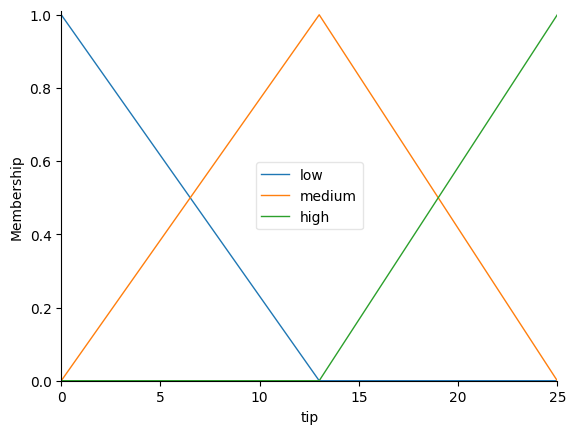

In [12]:
foodQuality.automf(3) 
serviceQuality.automf(3)

tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])      # Trójkąt o wierzchołkach: (0,0), (0,1), (13,0)
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])  # Trójkąt o wierzchołkach: (0,0), (13,1), (25,0)
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])   # Trójkąt o wierzchołkach: (13,0), (25,1), (25,0)

tip.view()

### ETAP 3: Inference (rules definitions)

In [13]:
rule1 = ctrl.Rule(foodQuality['poor'] | serviceQuality['poor'], tip['low'])
rule2 = ctrl.Rule(serviceQuality['average'], tip['medium'])
rule3 = ctrl.Rule(serviceQuality['good'] | foodQuality['good'], tip['high'])

# Tworzymy system sterowania (Control System)
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

# Tworzymy symulację - to tego obiektu będziemy używać do zadawania pytań
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

### ETAP 4: Defuzzification

Recommended tip is: 13.72%


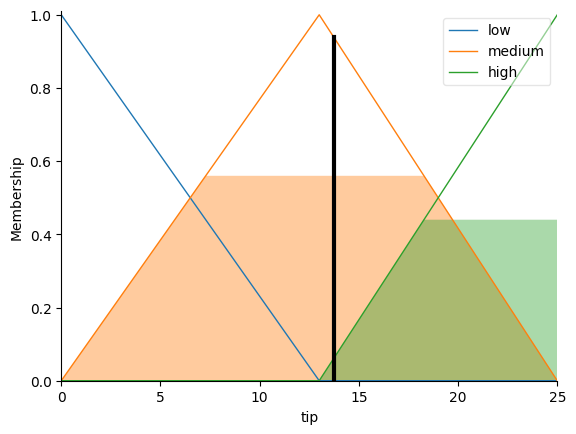

In [17]:
# Podajemy konkretne wartości (np. wystawiamy ocenę 6.5 dla jakości i 9.8 dla obsługi)
tipping.input['foodQuality'] = 6.5
tipping.input['serviceQuality'] = 7.2

# Wykonaj obliczenia (wnioskowanie rozmyte)
tipping.compute()

# Wyciągnij konkretną liczbę z wyjścia
print(f"Recommended tip is: {tipping.output['tip']:.2f}%")

# Opcjonalnie: można narysować wynik
tip.view(sim=tipping)